# Import

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import math
import seaborn as sns
import pickle
import copy

import torch
from torch import nn, Tensor

import time
import joblib

from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import Solver, ODESolver
from flow_matching.utils import ModelWrapper

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [38]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from fm.seed import set_seed
import fm.data as data
import fm.model as model
import fm.training as training
import fm.physics as physics
import fm.massesPlots as massesPlots
import fm.lossPlots as lossPlots
import fm.analysis as analysis

In [39]:
# for the plots :
import mplhep as hep

plt.style.use(hep.style.CMS)

plt.rcParams.update({
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 13,

    "lines.linewidth": 2,

    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "-",

    "legend.frameon": False,
})


# Load the Datasets

In [4]:
with open("df_H_event.pkl", "rb") as f:
    df_H_event = pickle.load(f)

with open("df_DY_event.pkl", "rb") as f:
    df_DY_event = pickle.load(f)

# Define the Training and Target Cols 

In [5]:
tau1_cols = [
    "tau1_logpt", "tau1_eta", "tau1_phi", "tau1_mass",
    "tau1_dxy", "tau1_dz",
    "tau1_ptCorrPNet", "tau1_rawPNetVSjet", "tau1_rawDeepTau2018v2p5VSjet",
    "tau1_charge",
    "tau1_dM_0", "tau1_dM_1", "tau1_dM_2", "tau1_dM_10", "tau1_dM_11",
    "tau1_leadTkDeltaEta", "tau1_leadTkDeltaPhi", "tau1_leadTkPtOverTauPt", 
    # "tau1_ptreco_over_ptgen",
 #   "gen_tau1_logpt"
]

tau2_cols = [
    "tau2_logpt", "tau2_eta", "tau2_phi", "tau2_mass",
    "tau2_dxy", "tau2_dz",
    "tau2_ptCorrPNet", "tau2_rawPNetVSjet", "tau2_rawDeepTau2018v2p5VSjet",
    "tau2_charge",
    "tau2_dM_0", "tau2_dM_1", "tau2_dM_2", "tau2_dM_10", "tau2_dM_11",
    "tau2_leadTkDeltaEta", "tau2_leadTkDeltaPhi", "tau2_leadTkPtOverTauPt", 
    # "tau2_ptreco_over_ptgen",
  #  "gen_tau2_logpt",
]

jet_cols = [
    "jet1_logpt", "jet1_eta", "jet1_phi", "jet1_mass",
    "jet2_logpt", "jet2_eta", "jet2_phi", "jet2_mass",
    "jet3_logpt", "jet3_eta", "jet3_phi", "jet3_mass",
]

met_cols = [
    "MET_logpt","MET_phi","MET_significance","MET_sumEt"
]

train_cols = (
    tau1_cols
    + tau2_cols
    + jet_cols
    + met_cols
)

y_cols = ["tau1_corr", "tau2_corr"]

# DataFrames + Splitting + Scaling

In [6]:
# Creo i dataframe : 
#   1. All
#   2. Bilanciato

df_all = (
    pd.concat([df_DY_event, df_H_event], axis=0)
      .sample(frac=1.0, random_state=42)
      .reset_index(drop=True)
)

df_bal = data.make_balanced_df(df_all, seed=0)

print("df_all:", df_all.shape)
print("df_bal:", df_bal.shape)
print("Counts df_all:", df_all["class"].value_counts().to_dict())
print("Counts df_bal:", df_bal["class"].value_counts().to_dict())

df_all: (337351, 76)
df_bal: (163894, 76)
Counts df_all: {1: 255404, 0: 81947}
Counts df_bal: {1: 81947, 0: 81947}


In [7]:
# Splitting :
df_train_all, df_val_all, df_test_all = data.split_df_once(df_all, seed=0)

print("SPLITS df_all:")
print("train:", df_train_all.shape, df_train_all["class"].value_counts().to_dict())
print("val  :", df_val_all.shape,   df_val_all["class"].value_counts().to_dict())
print("test :", df_test_all.shape,  df_test_all["class"].value_counts().to_dict())

df_train_bal, df_val_bal, df_test_bal = data.split_df_once(df_bal, seed=0)

print("SPLITS df_bal:")
print("train:", df_train_bal.shape, df_train_bal["class"].value_counts().to_dict())
print("val  :", df_val_bal.shape,   df_val_bal["class"].value_counts().to_dict())
print("test :", df_test_bal.shape,  df_test_bal["class"].value_counts().to_dict())

SPLITS df_all:
train: (269880, 76) {1: 204276, 0: 65604}
val  : (33735, 76) {1: 25636, 0: 8099}
test : (33736, 76) {1: 25492, 0: 8244}
SPLITS df_bal:
train: (131115, 76) {1: 65596, 0: 65519}
val  : (16389, 76) {0: 8228, 1: 8161}
test : (16390, 76) {0: 8200, 1: 8190}


In [8]:
# Scaling :
SCALING_MODES = [
    "X_NONE__Y_NONE",
    "X_GLOBAL__Y_LOCAL",
    "X_GLOBAL__Y_GLOBAL",
    "X_LOCAL__Y_LOCAL",
    "X_NONE__Y_LOCAL",
]

OUTDIR = "../results/prepared_splits"   # relativo a notebooks/
os.makedirs(OUTDIR, exist_ok=True)

In [9]:
def apply_and_save_all_scalings(
    df_train, df_val, df_test,
    dataset_tag: str,             # "unbalanced" o "balanced"
    train_cols, y_cols,
    outdir: str,
):
    base = os.path.join(outdir, dataset_tag)
    os.makedirs(base, exist_ok=True)

    saved_paths = {}

    for mode in SCALING_MODES:
        df_tr_s, df_va_s, df_te_s, scalers = data.prepare_splits_with_scaling(
            df_train, df_val, df_test,
            train_cols=train_cols,
            y_cols=y_cols,
            mode=mode,
            class_col="class",
        )

        mode_dir = os.path.join(base, mode)
        os.makedirs(mode_dir, exist_ok=True)

        # DataFrames scalati
        df_tr_s.to_pickle(os.path.join(mode_dir, "train.pkl"))
        df_va_s.to_pickle(os.path.join(mode_dir, "val.pkl"))
        df_te_s.to_pickle(os.path.join(mode_dir, "test.pkl"))

        # Scalers
        joblib.dump(scalers, os.path.join(mode_dir, "scalers.joblib"))

        saved_paths[mode] = mode_dir
        print(f"[{dataset_tag}] saved {mode} -> {mode_dir}")

    return saved_paths

In [10]:
# Non lo ri-runno, li ho già
paths_unbalanced = apply_and_save_all_scalings(
    df_train_all, df_val_all, df_test_all,
    dataset_tag="unbalanced",
    train_cols=train_cols,
    y_cols=y_cols,
    outdir=OUTDIR,
)

paths_balanced = apply_and_save_all_scalings(
    df_train_bal, df_val_bal, df_test_bal,
    dataset_tag="balanced",
    train_cols=train_cols,
    y_cols=y_cols,
    outdir=OUTDIR,
)

[unbalanced] saved X_NONE__Y_NONE -> ../results/prepared_splits/unbalanced/X_NONE__Y_NONE
[unbalanced] saved X_GLOBAL__Y_LOCAL -> ../results/prepared_splits/unbalanced/X_GLOBAL__Y_LOCAL
[unbalanced] saved X_GLOBAL__Y_GLOBAL -> ../results/prepared_splits/unbalanced/X_GLOBAL__Y_GLOBAL
[unbalanced] saved X_LOCAL__Y_LOCAL -> ../results/prepared_splits/unbalanced/X_LOCAL__Y_LOCAL
[unbalanced] saved X_NONE__Y_LOCAL -> ../results/prepared_splits/unbalanced/X_NONE__Y_LOCAL
[balanced] saved X_NONE__Y_NONE -> ../results/prepared_splits/balanced/X_NONE__Y_NONE
[balanced] saved X_GLOBAL__Y_LOCAL -> ../results/prepared_splits/balanced/X_GLOBAL__Y_LOCAL
[balanced] saved X_GLOBAL__Y_GLOBAL -> ../results/prepared_splits/balanced/X_GLOBAL__Y_GLOBAL
[balanced] saved X_LOCAL__Y_LOCAL -> ../results/prepared_splits/balanced/X_LOCAL__Y_LOCAL
[balanced] saved X_NONE__Y_LOCAL -> ../results/prepared_splits/balanced/X_NONE__Y_LOCAL


# Trainings 

In [11]:
def load_prepared(mode_dir: str):
    df_tr = pd.read_pickle(os.path.join(mode_dir, "train.pkl"))
    df_va = pd.read_pickle(os.path.join(mode_dir, "val.pkl"))
    df_te = pd.read_pickle(os.path.join(mode_dir, "test.pkl"))
    scalers = joblib.load(os.path.join(mode_dir, "scalers.joblib"))
    return df_tr, df_va, df_te, scalers

In [12]:
results_balanced_huber = {}

for mode, mode_dir in paths_balanced.items():
    print("\n" + "="*90)
    print(f"TRAIN BALANCED — {mode} (HUBER)")
    print("="*90)

    res = training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="huber",     # new
        huber_delta=1.0,       
    )

    results_balanced_huber[mode] = res


TRAIN BALANCED — X_NONE__Y_NONE (HUBER)
[ep    1] train=1.869796  val=0.445887  best=0.445887  bad=0/30
[ep   10] train=0.456486  val=0.466690  best=0.412059  bad=3/30
[ep   20] train=0.478743  val=0.437993  best=0.404498  bad=7/30
[ep   30] train=0.404750  val=0.461226  best=0.400394  bad=6/30
[ep   40] train=0.421621  val=0.583035  best=0.384100  bad=6/30
[ep   50] train=0.337305  val=0.432428  best=0.273604  bad=2/30
[ep   60] train=0.297944  val=0.342265  best=0.273604  bad=12/30
[ep   70] train=0.276141  val=0.221804  best=0.221804  bad=0/30
[ep   80] train=0.280249  val=0.331667  best=0.221804  bad=10/30
[ep   90] train=0.255640  val=0.257014  best=0.221804  bad=20/30
[ep  100] train=0.272735  val=0.351159  best=0.221804  bad=30/30
Early stopping at ep 100 (best val=0.221804)

TRAIN BALANCED — X_GLOBAL__Y_LOCAL (HUBER)
[ep    1] train=0.651597  val=0.671932  best=0.671932  bad=0/30
[ep   10] train=0.544141  val=0.528536  best=0.525252  bad=1/30
[ep   20] train=0.485258  val=0.45

In [13]:
results_unbalanced_huber = {}

for mode, mode_dir in paths_unbalanced.items():
    print("\n" + "="*90)
    print(f"TRAIN UNBALANCED — {mode} (HUBER)")
    print("="*90)

    res= training.train_one_mode(
        mode_dir=mode_dir,
        train_cols=train_cols,
        y_cols=y_cols,
        loss_type="huber",     # new
        huber_delta=1.0,       
    )

    results_unbalanced_huber[mode] = res


TRAIN UNBALANCED — X_NONE__Y_NONE (HUBER)
[ep    1] train=0.792522  val=0.464217  best=0.464217  bad=0/30
[ep   10] train=0.484750  val=0.454812  best=0.440148  bad=4/30
[ep   20] train=0.366050  val=0.335437  best=0.335437  bad=0/30
[ep   30] train=0.309574  val=0.332645  best=0.291111  bad=1/30
[ep   40] train=0.280436  val=0.298813  best=0.275416  bad=1/30
[ep   50] train=0.277664  val=0.281000  best=0.267145  bad=7/30
[ep   60] train=0.258393  val=0.254996  best=0.254996  bad=0/30
[ep   70] train=0.257876  val=0.312633  best=0.244349  bad=5/30
[ep   80] train=0.252895  val=0.254121  best=0.237772  bad=1/30
[ep   90] train=0.242706  val=0.235140  best=0.228389  bad=1/30
[ep  100] train=0.237142  val=0.227696  best=0.223735  bad=7/30
[ep  110] train=0.237524  val=0.222835  best=0.222835  bad=0/30
[ep  120] train=0.235749  val=0.268622  best=0.222835  bad=10/30
[ep  130] train=0.294649  val=0.260559  best=0.221494  bad=5/30
[ep  140] train=0.231078  val=0.226319  best=0.221494  bad=1

In [14]:
# Salvo i run HUBER
OUT_ROOT = "../results/runs_prepared"
dataset_tag = "balanced"
loss_tag = "HUBER_d1"  

for mode, res in results_balanced_huber.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

saved -> ../results/runs_prepared/balanced/HUBER_d1/X_NONE__Y_NONE
saved -> ../results/runs_prepared/balanced/HUBER_d1/X_GLOBAL__Y_LOCAL
saved -> ../results/runs_prepared/balanced/HUBER_d1/X_GLOBAL__Y_GLOBAL
saved -> ../results/runs_prepared/balanced/HUBER_d1/X_LOCAL__Y_LOCAL
saved -> ../results/runs_prepared/balanced/HUBER_d1/X_NONE__Y_LOCAL


In [15]:
dataset_tag = "unbalanced"
loss_tag = "HUBER_d1"

for mode, res in results_unbalanced_huber.items():
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    training.save_run(res, save_dir)
    print(f"saved -> {save_dir}")

saved -> ../results/runs_prepared/unbalanced/HUBER_d1/X_NONE__Y_NONE
saved -> ../results/runs_prepared/unbalanced/HUBER_d1/X_GLOBAL__Y_LOCAL
saved -> ../results/runs_prepared/unbalanced/HUBER_d1/X_GLOBAL__Y_GLOBAL
saved -> ../results/runs_prepared/unbalanced/HUBER_d1/X_LOCAL__Y_LOCAL
saved -> ../results/runs_prepared/unbalanced/HUBER_d1/X_NONE__Y_LOCAL


# Predictions - Huber

In [16]:
preds_bal_huber = {}

for mode in SCALING_MODES:
    res = results_balanced_huber[mode]  
    df_pred = model.predict_tau_corr_auto(
        df=df_test_bal,   # RAW
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )
    preds_bal_huber[mode] = df_pred
    print(mode, "HUBER done", df_pred.shape)



preds_unbal_huber = {}

for mode in SCALING_MODES:
    res = results_unbalanced_huber[mode]  
    df_pred = model.predict_tau_corr_auto(
        df=df_test_all,
        res=res,
        train_cols=train_cols,
        y_cols=y_cols,
    )
    preds_unbal_huber[mode] = df_pred
    print(mode, "HUBER done", df_pred.shape)

X_NONE__Y_NONE HUBER done (16390, 2)
X_GLOBAL__Y_LOCAL HUBER done (16390, 2)
X_GLOBAL__Y_GLOBAL HUBER done (16390, 2)
X_LOCAL__Y_LOCAL HUBER done (16390, 2)
X_NONE__Y_LOCAL HUBER done (16390, 2)
X_NONE__Y_NONE HUBER done (33736, 2)
X_GLOBAL__Y_LOCAL HUBER done (33736, 2)
X_GLOBAL__Y_GLOBAL HUBER done (33736, 2)
X_LOCAL__Y_LOCAL HUBER done (33736, 2)
X_NONE__Y_LOCAL HUBER done (33736, 2)


# Plots

In [17]:
masses_bal_huber = {}

for mode in SCALING_MODES:
    
    dfp = preds_bal_huber[mode]  
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_bal["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau1_eta"].to_numpy(),
        df_test_bal["tau1_phi"].to_numpy(),
        df_test_bal["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_bal["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_bal["tau2_eta"].to_numpy(),
        df_test_bal["tau2_phi"].to_numpy(),
        df_test_bal["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_bal_huber[mode] = m
    print(mode, "HUBER done:", float(np.mean(m)), float(np.std(m)))

X_NONE__Y_NONE HUBER done: 111.81076105767502 36.911643820868704
X_GLOBAL__Y_LOCAL HUBER done: 109.06784243428159 21.868364165380992
X_GLOBAL__Y_GLOBAL HUBER done: 109.96219029034738 24.552820444945482
X_LOCAL__Y_LOCAL HUBER done: 110.32928435294227 24.01962888997306
X_NONE__Y_LOCAL HUBER done: 110.38343690143421 32.17616021083217


In [18]:
masses_unbal_huber = {}

for mode in SCALING_MODES:
    
    dfp = preds_unbal_huber[mode]
    
    m = physics.inv_mass_two_taus_corrected_ratio(
        df_test_all["tau1_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau1_eta"].to_numpy(),
        df_test_all["tau1_phi"].to_numpy(),
        df_test_all["tau1_mass"].to_numpy(),
        dfp["tau1_corr_pred"].to_numpy(),

        df_test_all["tau2_pt_reco_corrPNet"].to_numpy(),
        df_test_all["tau2_eta"].to_numpy(),
        df_test_all["tau2_phi"].to_numpy(),
        df_test_all["tau2_mass"].to_numpy(),
        dfp["tau2_corr_pred"].to_numpy(),
    )

    masses_unbal_huber[mode] = m
    print(mode, "HUBER done:", float(np.mean(m)), float(np.std(m)))

X_NONE__Y_NONE HUBER done: 119.20043270681316 25.636741281086767
X_GLOBAL__Y_LOCAL HUBER done: 116.93021647312798 16.43490099254385
X_GLOBAL__Y_GLOBAL HUBER done: 116.96319680567979 18.72751510817498
X_LOCAL__Y_LOCAL HUBER done: 117.2230459947667 19.18460188153351
X_NONE__Y_LOCAL HUBER done: 118.12077975120818 23.956623217484008


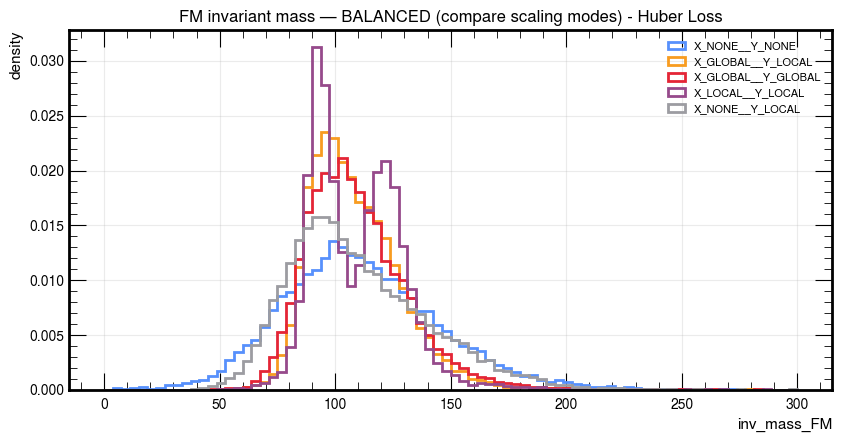

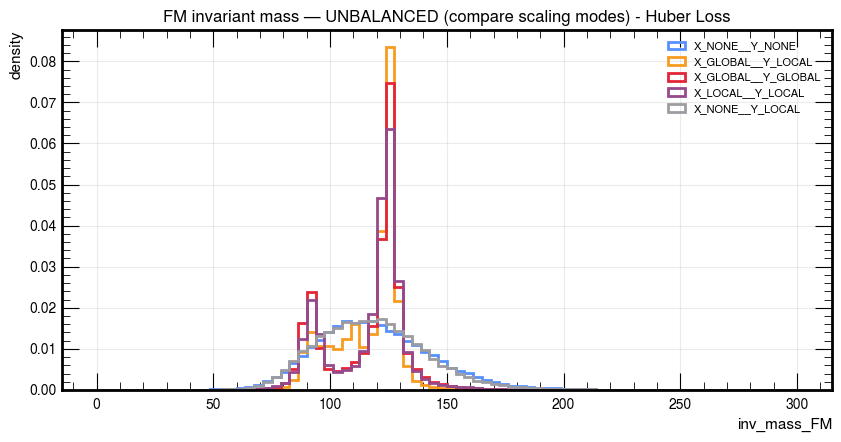

In [19]:
massesPlots.plot_mass_overlay(
    masses_bal_huber,
    title="FM invariant mass — BALANCED (compare scaling modes) - Huber Loss",
    bins=80,
    range_=(0, 300), 
    density=True,
)

massesPlots.plot_mass_overlay(
    masses_unbal_huber,
    title="FM invariant mass — UNBALANCED (compare scaling modes) - Huber Loss",
    bins=80,
    range_=(0, 300),
    density=True,
)

In [20]:
# Per separare i plot :

m_dy_bal = (df_test_bal["class"].to_numpy() == 0)
m_h_bal  = (df_test_bal["class"].to_numpy() == 1)

m_dy_unb = (df_test_all["class"].to_numpy() == 0)
m_h_unb  = (df_test_all["class"].to_numpy() == 1)

# BALANCED
masses_bal_dy_huber = {mode: np.asarray(masses_bal_huber[mode])[m_dy_bal] for mode in SCALING_MODES}
masses_bal_h_huber  = {mode: np.asarray(masses_bal_huber[mode])[m_h_bal]  for mode in SCALING_MODES}

# UNBALANCED
masses_unb_dy_huber = {mode: np.asarray(masses_unbal_huber[mode])[m_dy_unb] for mode in SCALING_MODES}
masses_unb_h_huber  = {mode: np.asarray(masses_unbal_huber[mode])[m_h_unb]  for mode in SCALING_MODES}

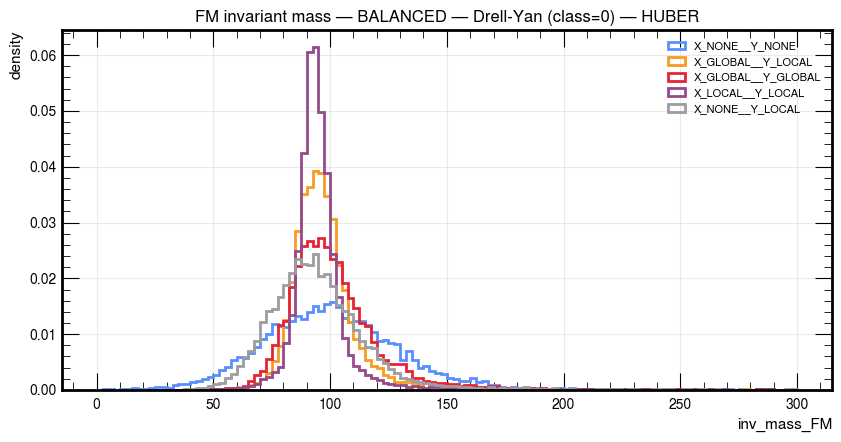

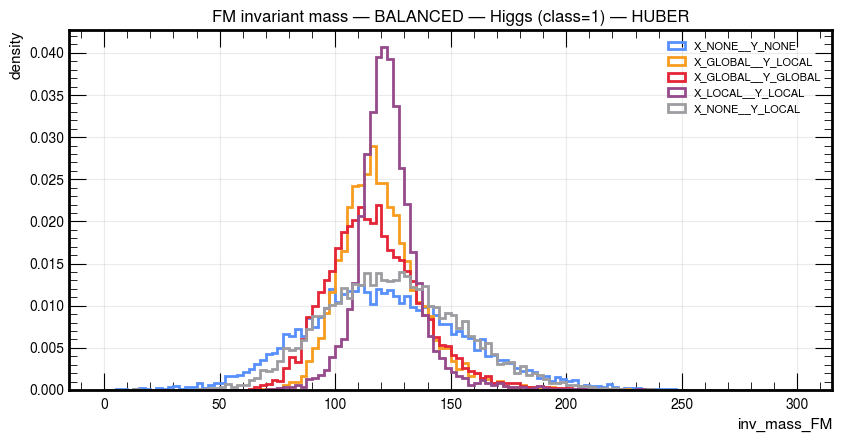

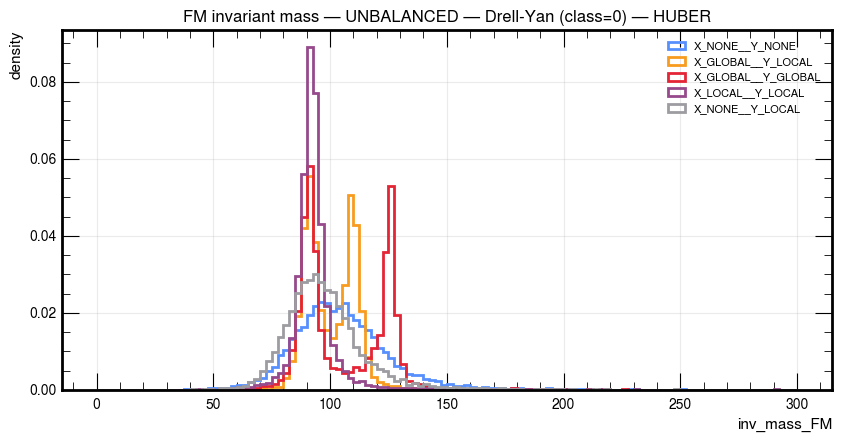

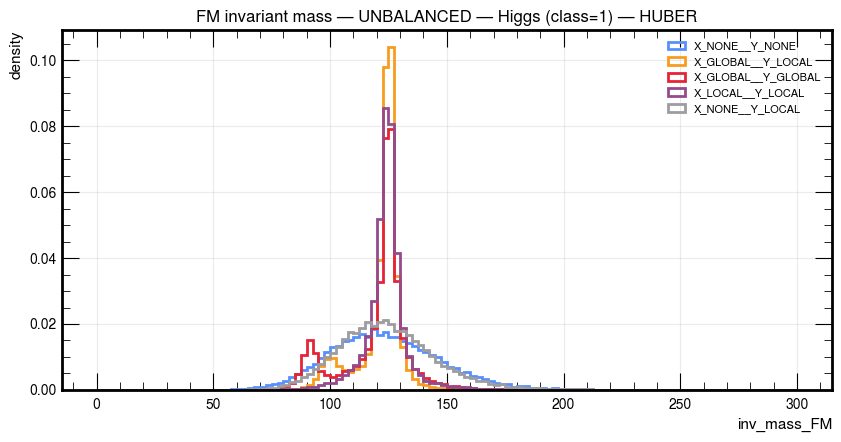

In [21]:
common_range = (0, 300)

# BALANCED — HUBER
massesPlots.plot_mass_overlay(
    masses_bal_dy_huber,
    title="FM invariant mass — BALANCED — Drell-Yan (class=0) — HUBER",
    bins=120,
    range_=common_range,
    density=True,
)

massesPlots.plot_mass_overlay(
    masses_bal_h_huber,
    title="FM invariant mass — BALANCED — Higgs (class=1) — HUBER",
    bins=120,
    range_=common_range,
    density=True,
)

# UNBALANCED — HUBER
massesPlots.plot_mass_overlay(
    masses_unb_dy_huber,
    title="FM invariant mass — UNBALANCED — Drell-Yan (class=0) — HUBER",
    bins=120,
    range_=common_range,
    density=True,
)

massesPlots.plot_mass_overlay(
    masses_unb_h_huber,
    title="FM invariant mass — UNBALANCED — Higgs (class=1) — HUBER",
    bins=120,
    range_=common_range,
    density=True,
)

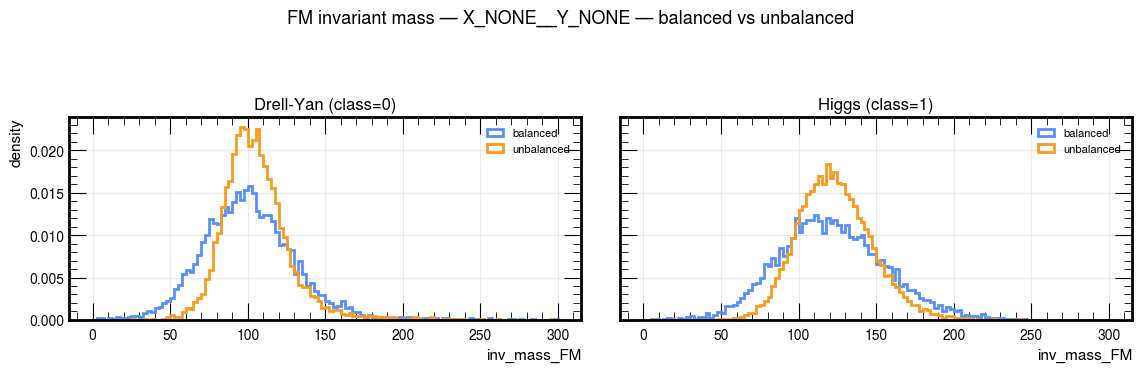

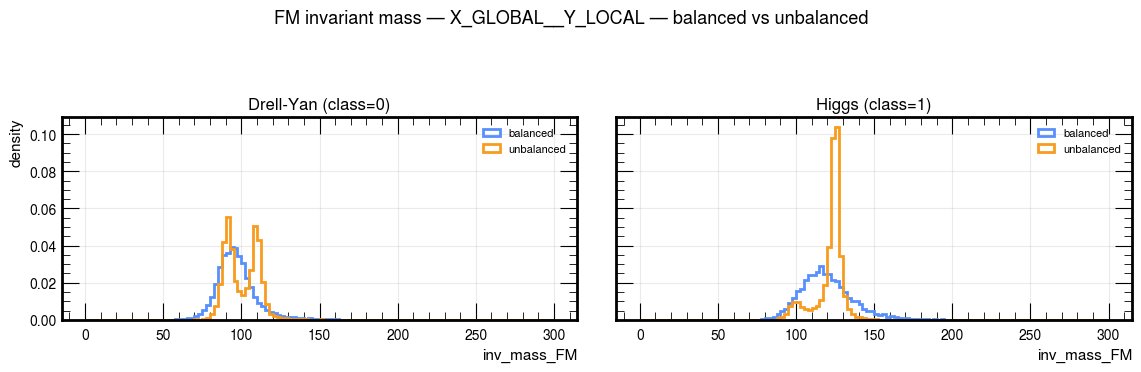

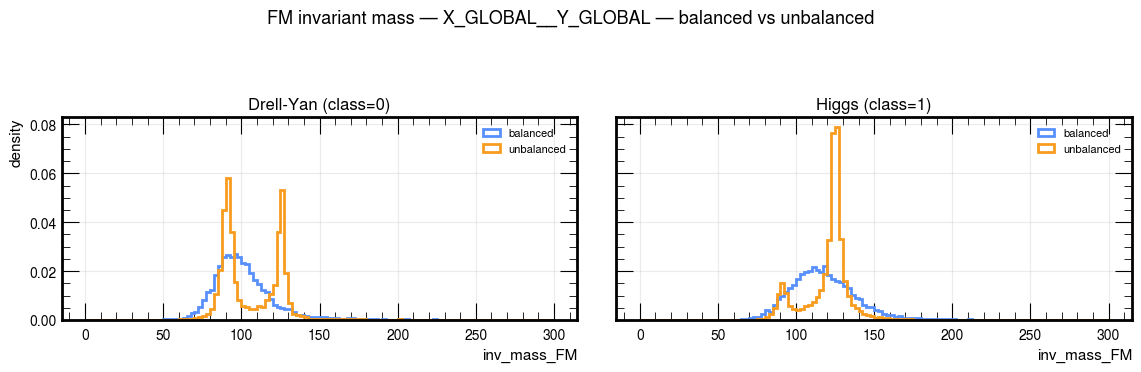

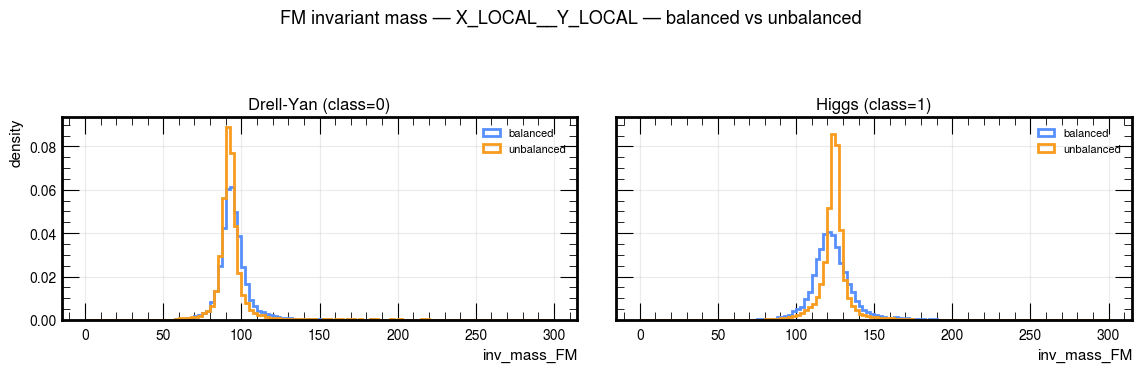

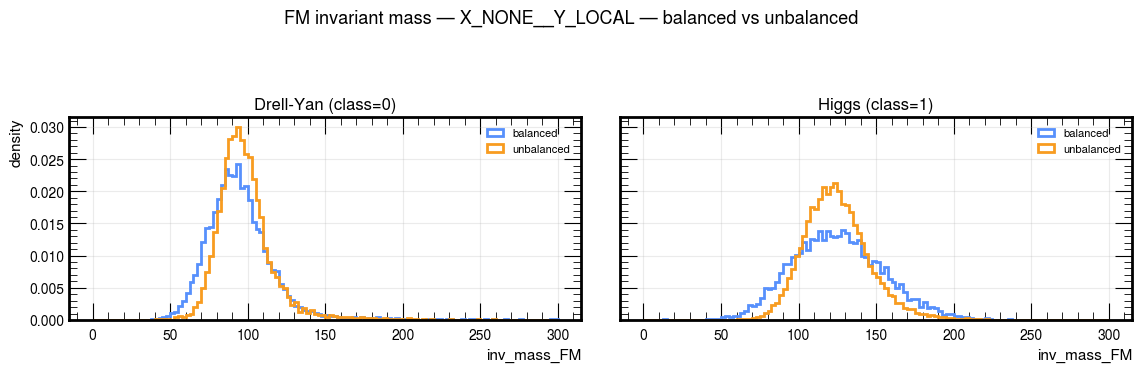

In [22]:
massesPlots.plot_balanced_vs_unbalanced_by_mode(
    masses_bal=masses_bal_huber,
    masses_unbal=masses_unbal_huber,
    df_test_bal=df_test_bal,
    df_test_unbal=df_test_all,
    scaling_modes=SCALING_MODES,
    bins=120,
    range_=(0, 300), 
    density=True,
)

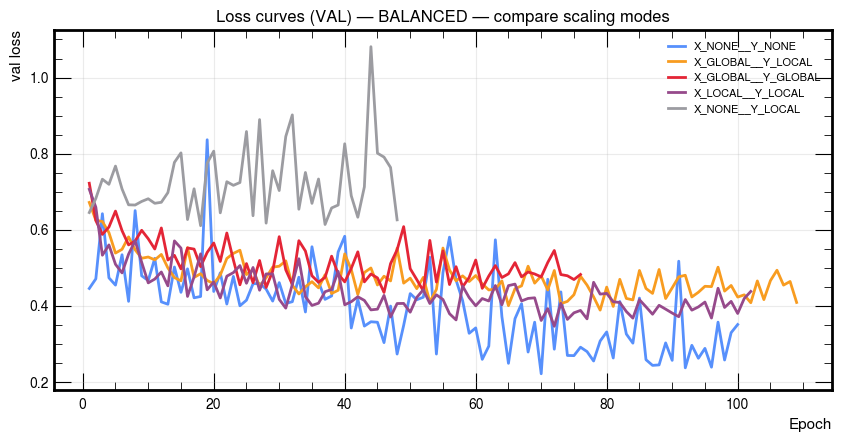

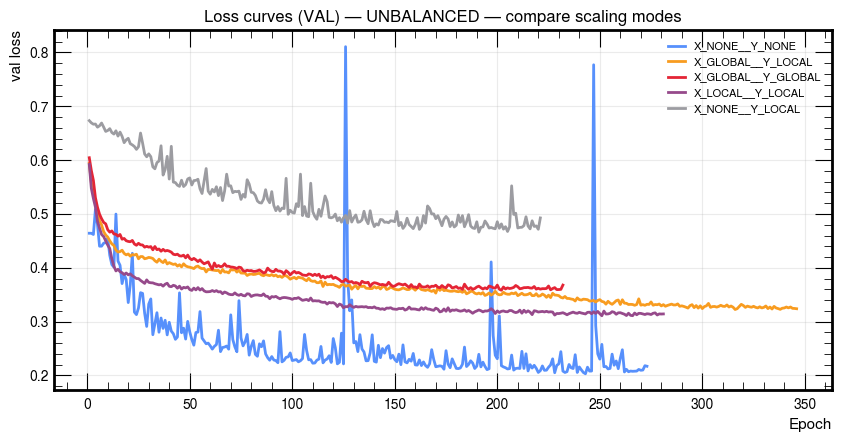

In [23]:
lossPlots.plot_loss_overlay(
    results_balanced_huber,
    title="Loss curves (VAL) — BALANCED — compare scaling modes",
    which="val",
    logy=False,      
)

lossPlots.plot_loss_overlay(
    results_unbalanced_huber,
    title="Loss curves (VAL) — UNBALANCED — compare scaling modes",
    which="val",
)

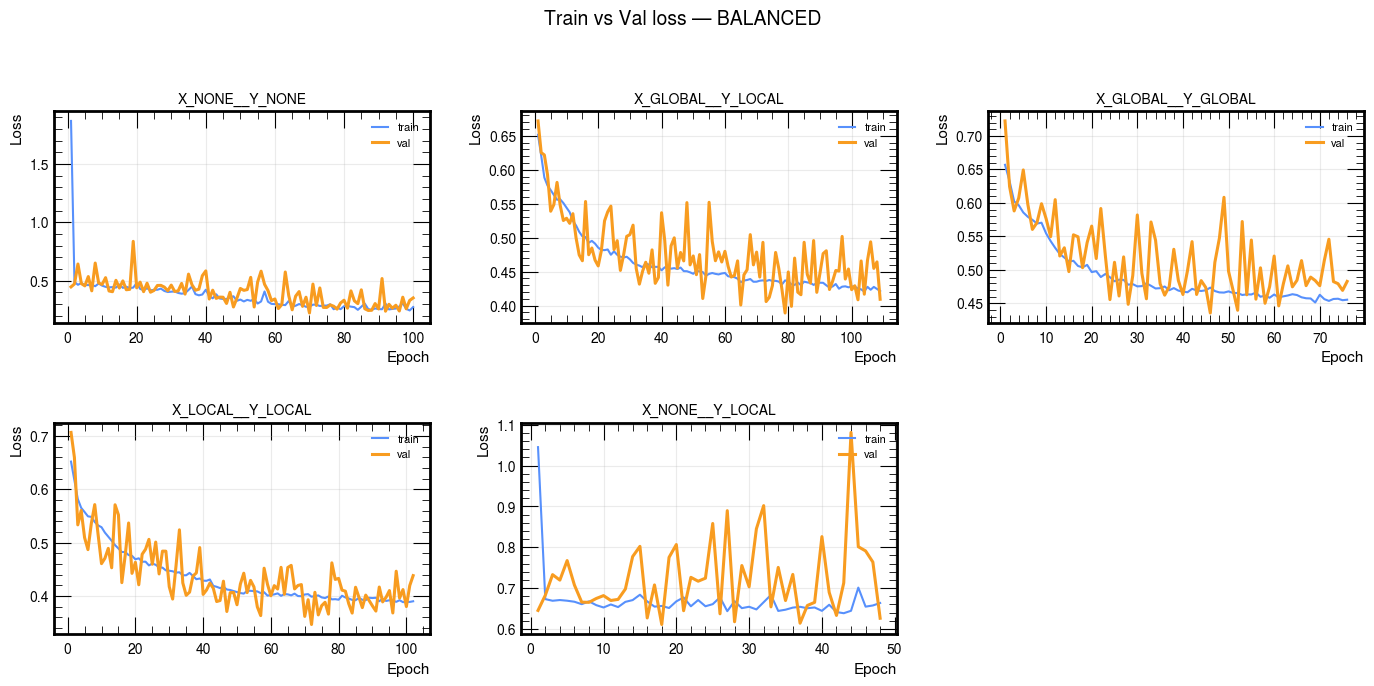

In [24]:
lossPlots.plot_loss_grid(
    results_balanced_huber,
    title="Train vs Val loss — BALANCED",
    order=SCALING_MODES,
    ncols=3,
)

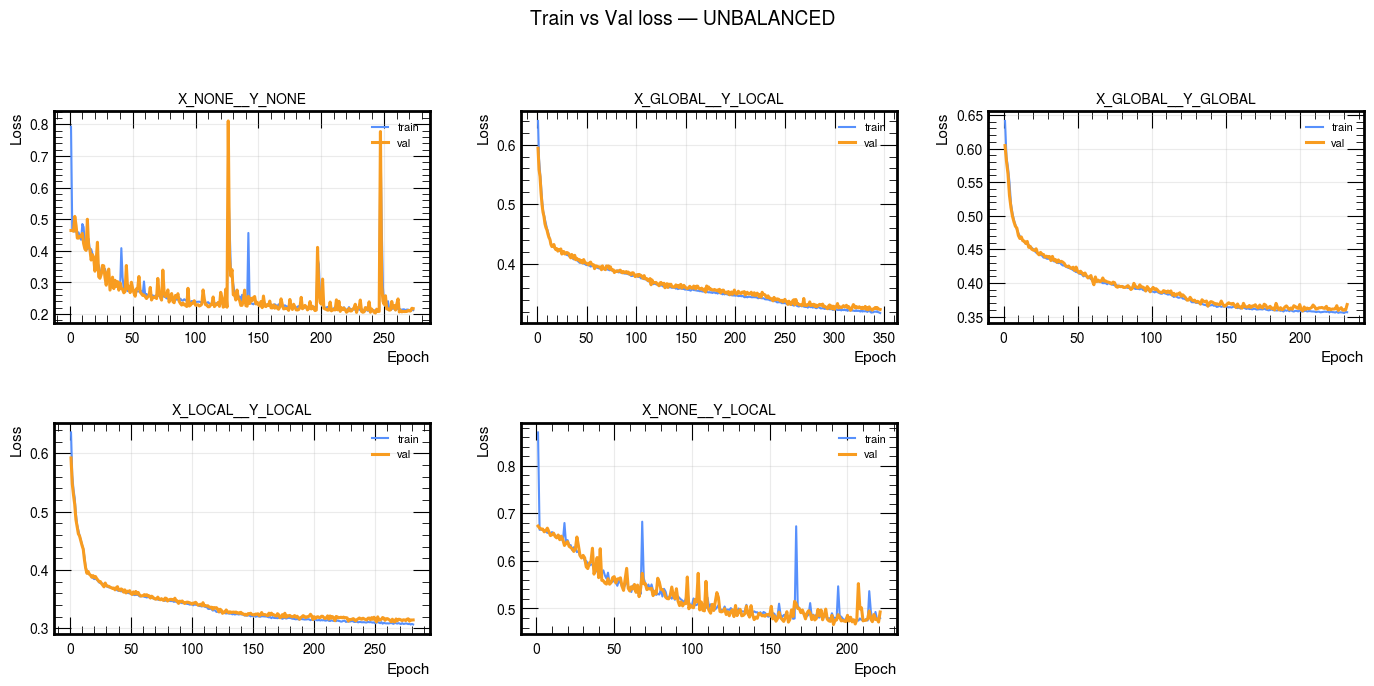

In [25]:
lossPlots.plot_loss_grid(
    results_unbalanced_huber,
    title="Train vs Val loss — UNBALANCED",
    order=SCALING_MODES,
    ncols=3,
)

# Analysis
- S/B within the window (110-130) GeV

In [26]:
print("S/B:")
tab_long, tab_pivot = analysis.compute_S_over_B_all_modes(
    masses_bal=masses_bal_huber,
    masses_unbal=masses_unbal_huber,
    df_test_bal=df_test_bal,
    df_test_unbal=df_test_all,
    scaling_modes=SCALING_MODES,
    window=(110,130),
    save_csv=True,
)

tab_pivot

S/B:


,mode,balanced,unbalanced
0,X_GLOBAL__Y_GLOBAL,2.216040,5.462126
1,X_GLOBAL__Y_LOCAL,5.122503,12.179748
2,X_LOCAL__Y_LOCAL,14.930168,105.376289
3,X_NONE__Y_LOCAL,2.029135,9.577478
4,X_NONE__Y_NONE,1.124096,4.160078


## CHECK :

In [27]:
# Conto separatamente S e M per il best mode:
tab_long[tab_long["mode"] == "X_LOCAL__Y_LOCAL"]

,dataset,mode,window,N_S,N_B,S_over_B,S_over_sqrtB
6,balanced,X_LOCAL__Y_LOCAL,110-130,5345,358,14.930168,282.492028
7,unbalanced,X_LOCAL__Y_LOCAL,110-130,20443,194,105.376289,1467.721864


# Comparison MSE vs Huber Loss

In [40]:
# Carico le run :
results_balanced_mse = {}

OUT_ROOT = "../results/runs_prepared"
dataset_tag = "balanced"

for mode in SCALING_MODES:
    save_dir = os.path.join(OUT_ROOT, dataset_tag, mode) 
    res = training.load_run(save_dir)
    results_balanced_mse[mode] = res
    print("Loaded MSE:", mode)



results_balanced_huber = {}

loss_tag = "HUBER_d1"

for mode in SCALING_MODES:
    save_dir = os.path.join(OUT_ROOT, dataset_tag, loss_tag, mode)
    res = training.load_run(save_dir)
    results_balanced_huber[mode] = res
    print("Loaded HUBER:", mode)

Loaded MSE: X_NONE__Y_NONE
Loaded MSE: X_GLOBAL__Y_LOCAL
Loaded MSE: X_GLOBAL__Y_GLOBAL
Loaded MSE: X_LOCAL__Y_LOCAL
Loaded MSE: X_NONE__Y_LOCAL
Loaded HUBER: X_NONE__Y_NONE
Loaded HUBER: X_GLOBAL__Y_LOCAL
Loaded HUBER: X_GLOBAL__Y_GLOBAL
Loaded HUBER: X_LOCAL__Y_LOCAL
Loaded HUBER: X_NONE__Y_LOCAL


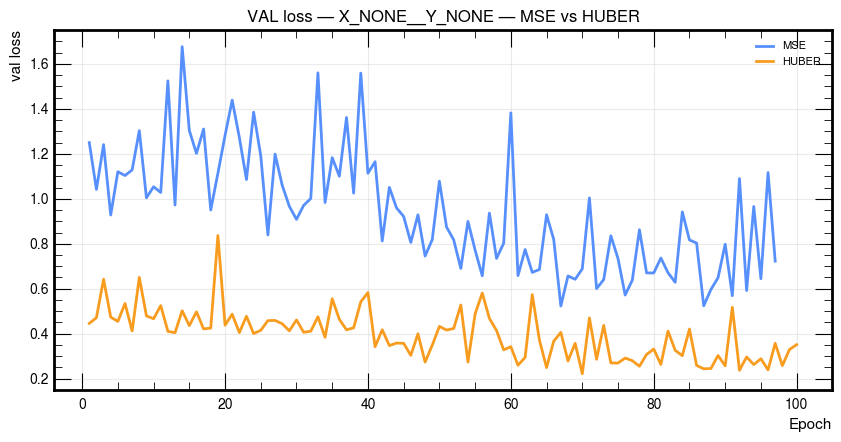

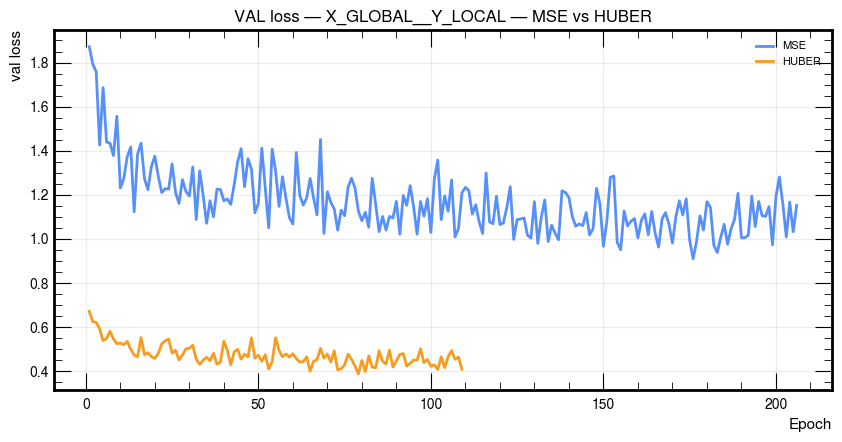

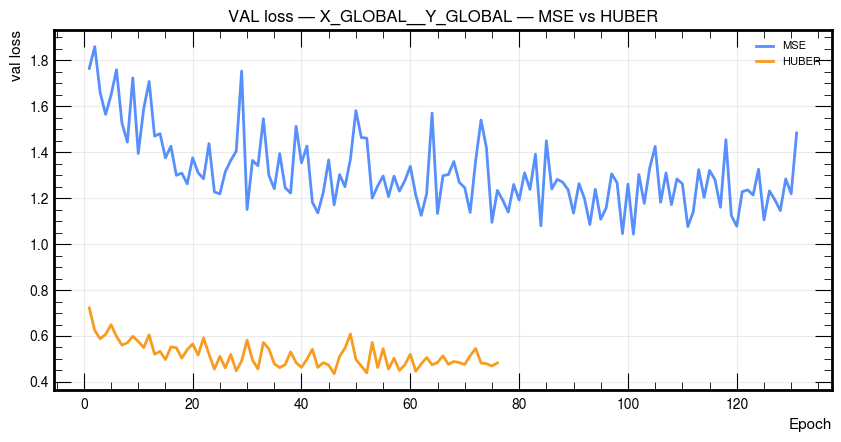

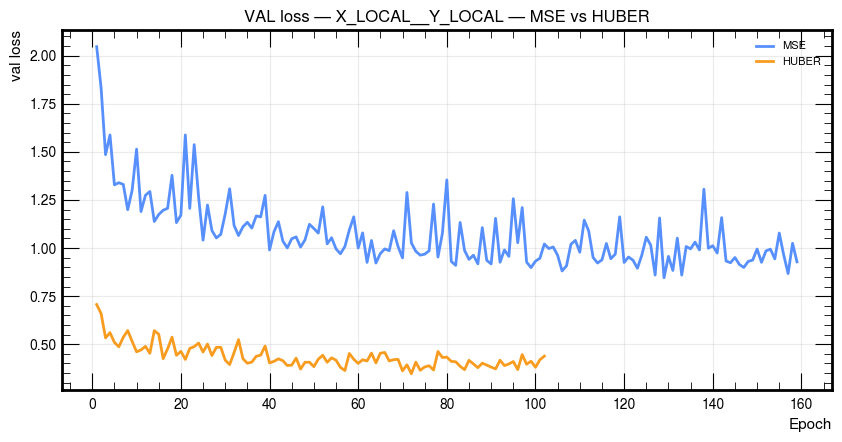

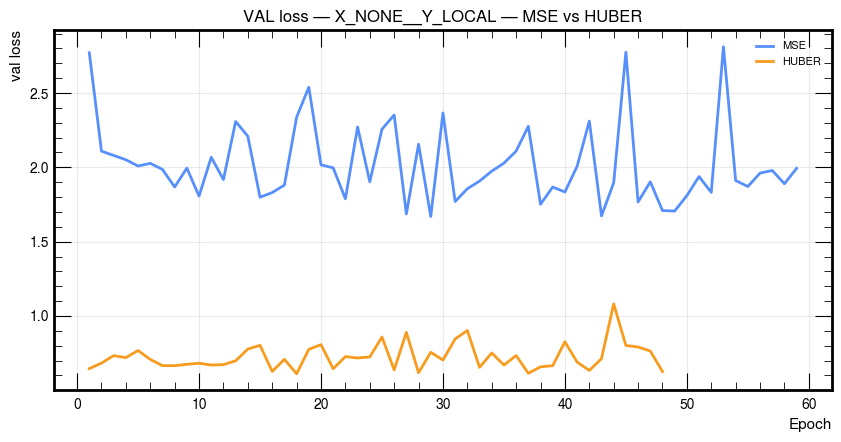

In [41]:
for mode in SCALING_MODES:

    lossPlots.plot_loss_overlay(
        {
            "MSE": results_balanced_mse[mode],
            "HUBER": results_balanced_huber[mode],
        },
        title=f"VAL loss — {mode} — MSE vs HUBER",
        which="val",
        logy=False,
    )

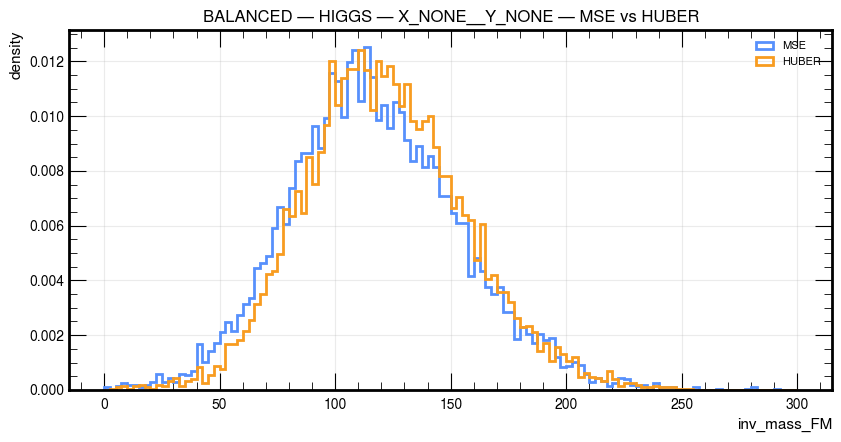

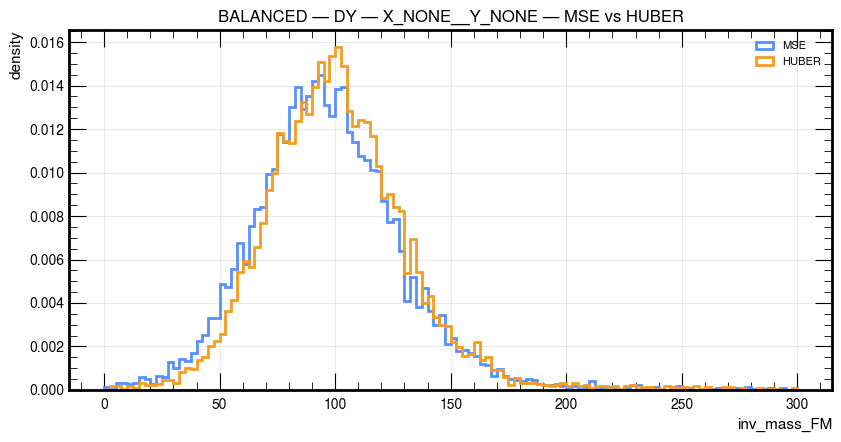

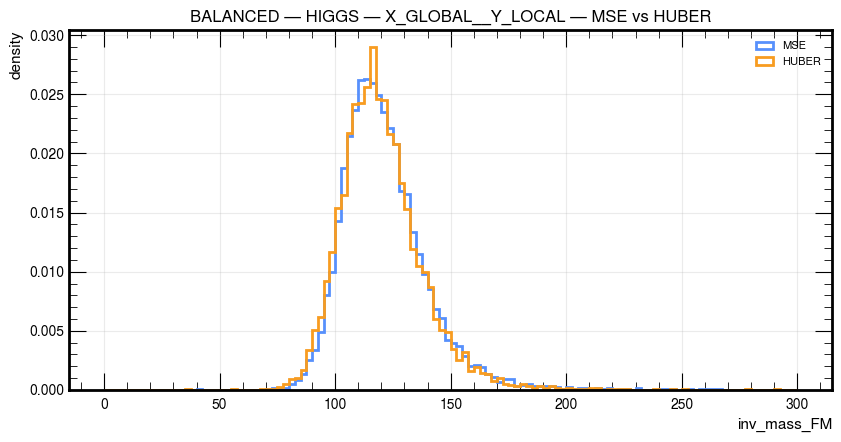

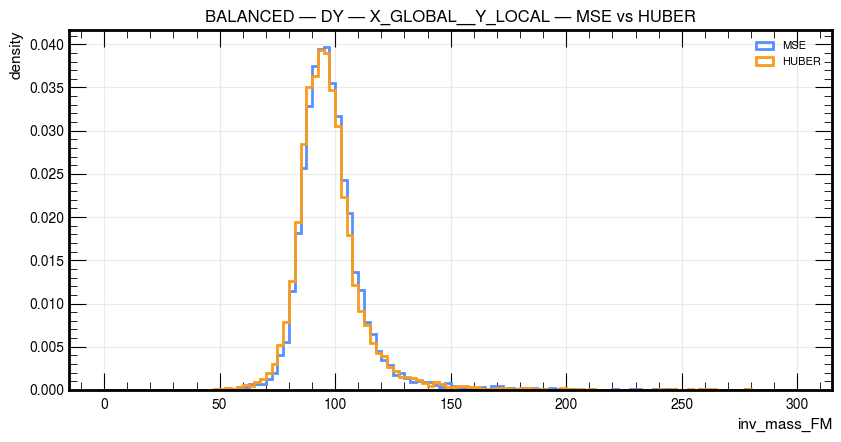

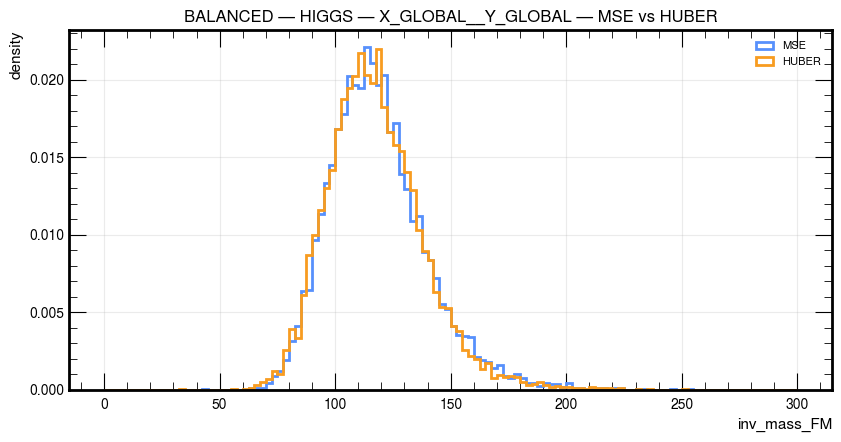

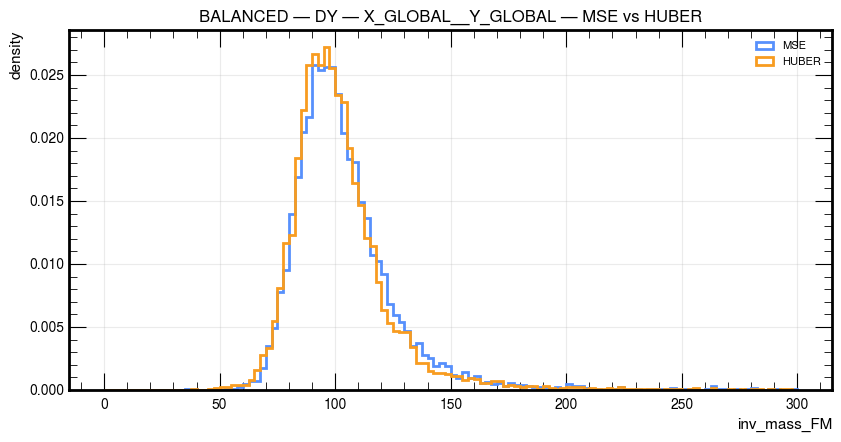

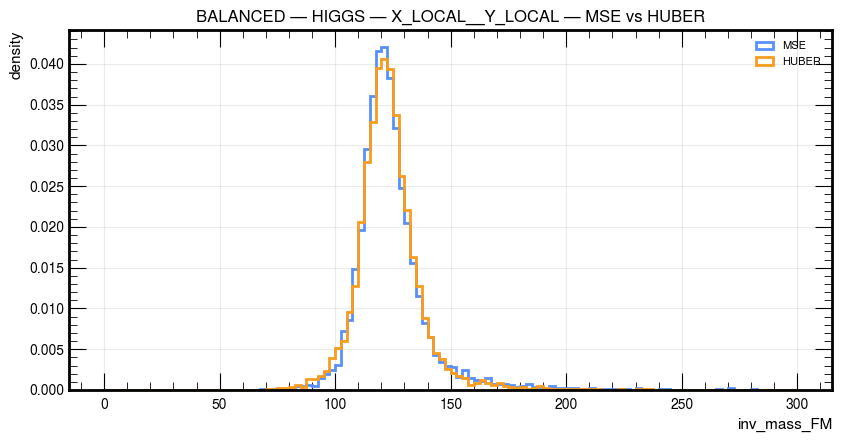

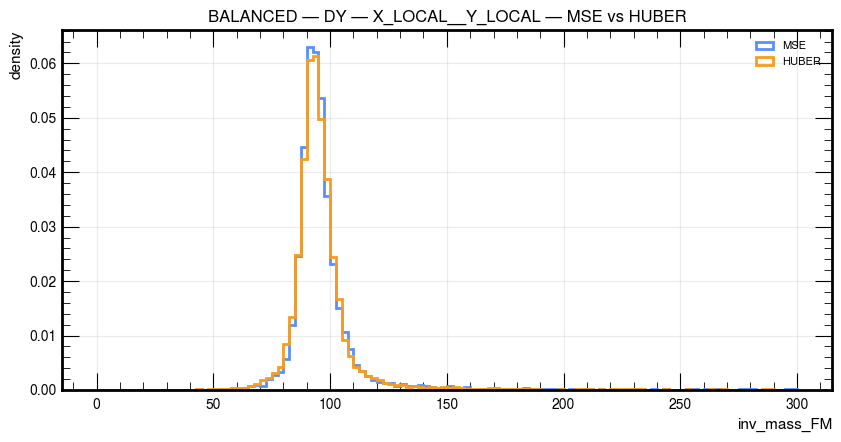

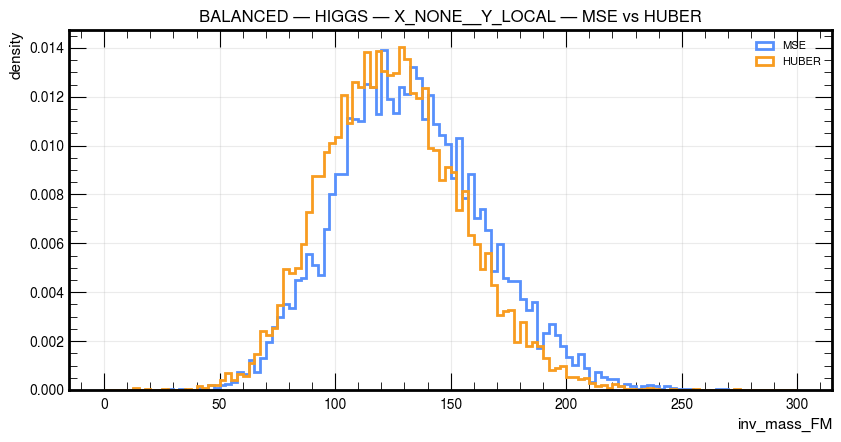

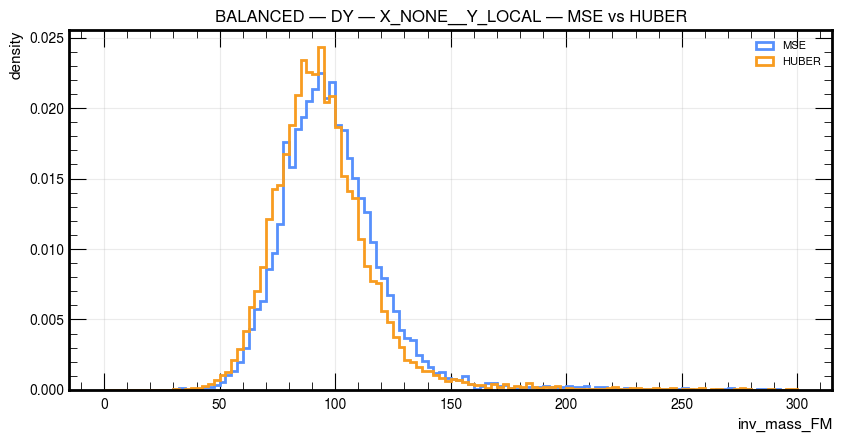

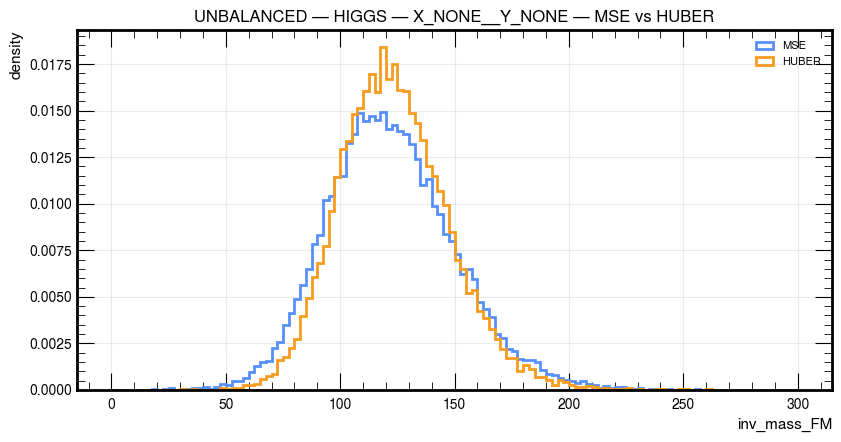

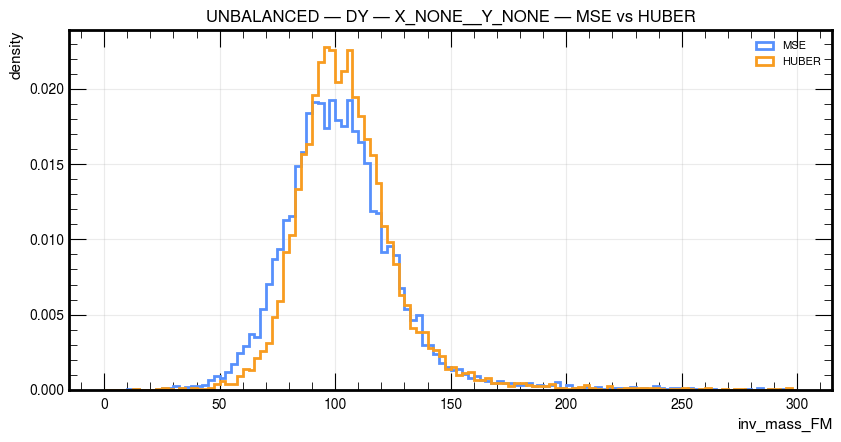

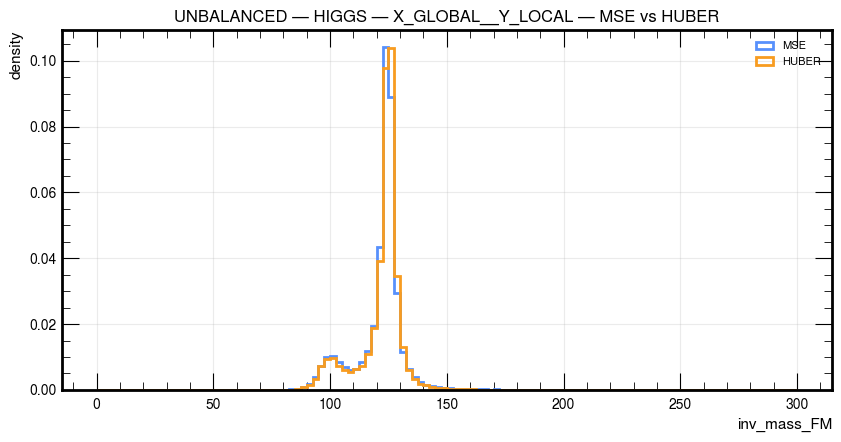

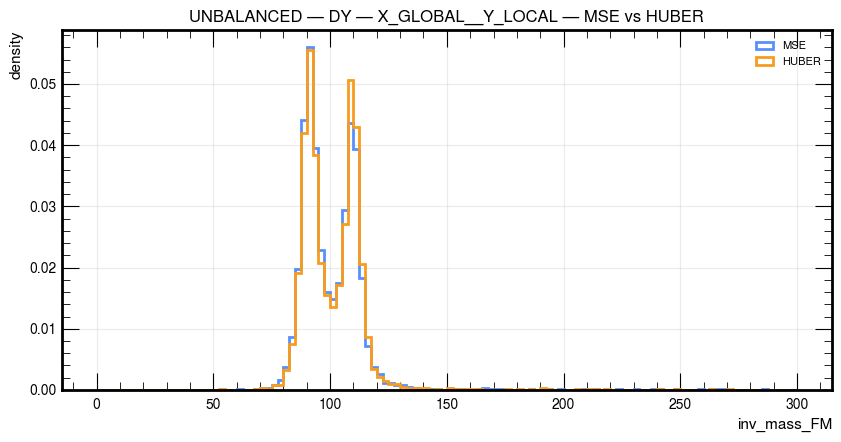

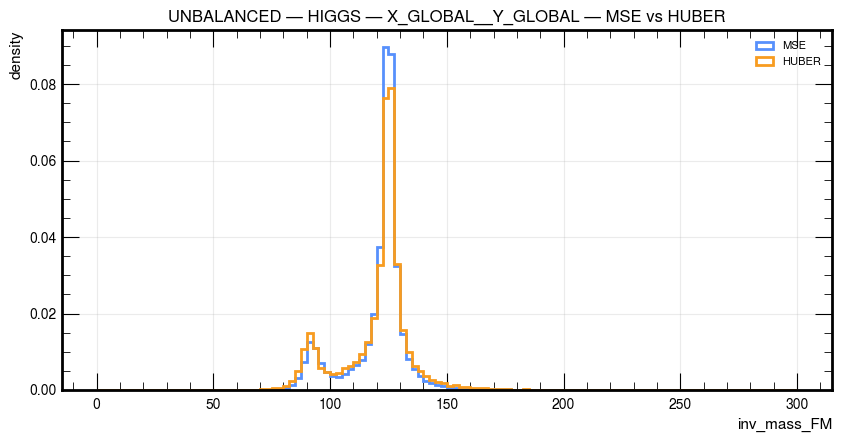

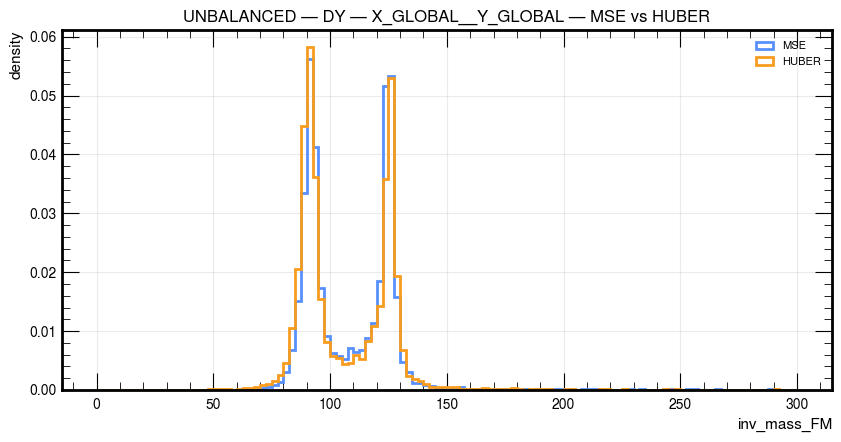

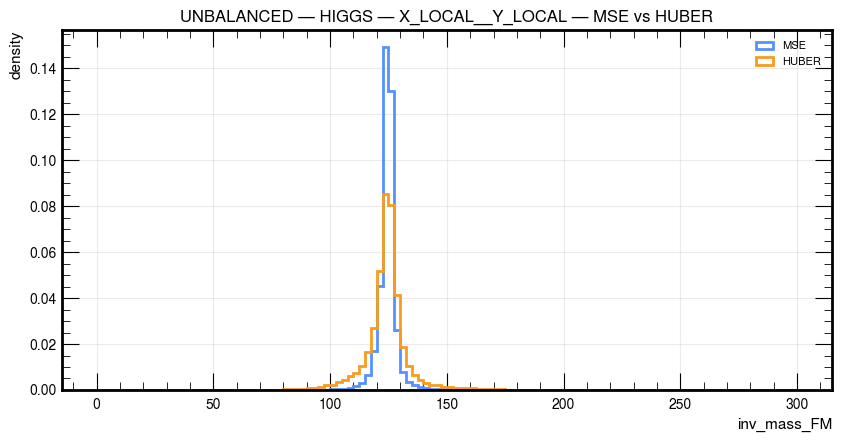

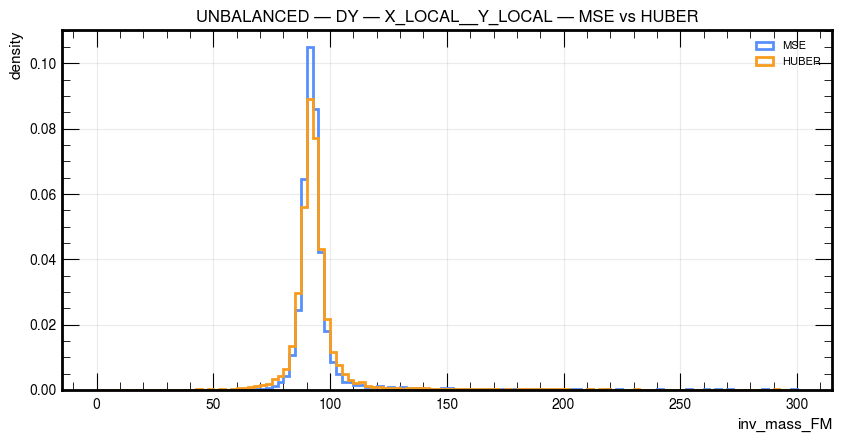

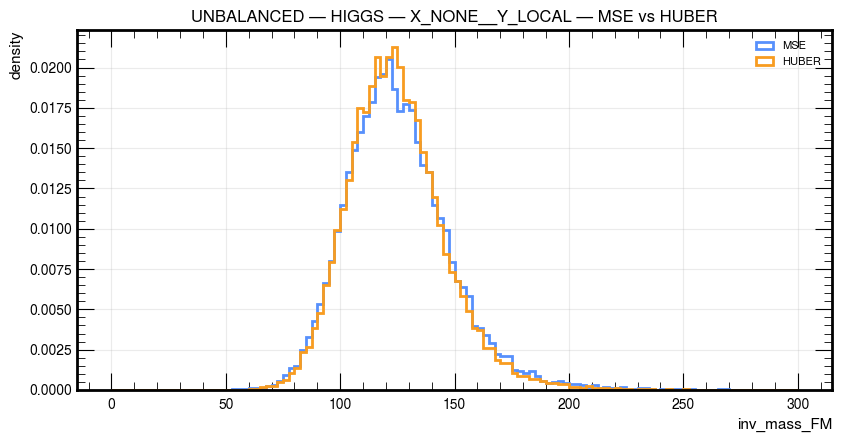

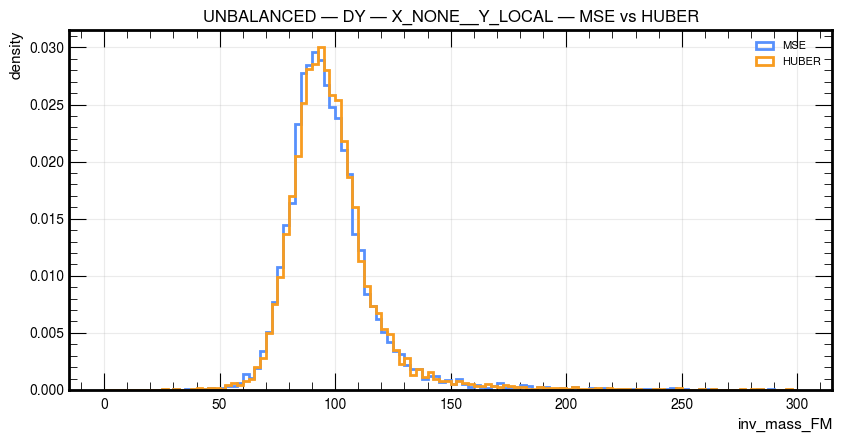

In [57]:
# Carico le masse MSE :
bal_npz = np.load("../results/masses/masses_bal_mse.npz")
masses_bal_mse = {mode: bal_npz[mode] for mode in SCALING_MODES}

unb_npz = np.load("../results/masses/masses_unbal_mse.npz")
masses_unbal_mse = {mode: unb_npz[mode] for mode in SCALING_MODES}

# mask per le classi
m_dy_bal = (df_test_bal["class"].to_numpy() == 0)
m_h_bal  = (df_test_bal["class"].to_numpy() == 1)

m_dy_unb = (df_test_all["class"].to_numpy() == 0)
m_h_unb  = (df_test_all["class"].to_numpy() == 1)

masses_bal_dy = {
    mode: np.asarray(masses_bal_mse[mode])[m_dy_bal]
    for mode in SCALING_MODES
}

masses_bal_h = {
    mode: np.asarray(masses_bal_mse[mode])[m_h_bal]
    for mode in SCALING_MODES
}

masses_unbal_dy = {
    mode: np.asarray(masses_unbal_mse[mode])[m_dy_unb]
    for mode in SCALING_MODES
}

masses_unbal_h = {
    mode: np.asarray(masses_unbal_mse[mode])[m_h_unb]
    for mode in SCALING_MODES
}

for mode in SCALING_MODES:
    massesPlots.plot_mass_overlay(
        {
            "MSE": masses_bal_h[mode],
            "HUBER": masses_bal_h_huber[mode],
        },
        title=f"BALANCED — HIGGS — {mode} — MSE vs HUBER",
        bins=120,
        range_=common_range,
        density=True,
    )
    massesPlots.plot_mass_overlay(
        {
            "MSE": masses_bal_dy[mode],
            "HUBER": masses_bal_dy_huber[mode],
        },
        title=f"BALANCED — DY — {mode} — MSE vs HUBER",
        bins=120,
        range_=common_range,
        density=True,
    )

for mode in SCALING_MODES:
    massesPlots.plot_mass_overlay(
        {
            "MSE": masses_unbal_h[mode],
            "HUBER": masses_unbal_h_huber[mode],
        },
        title=f"UNBALANCED — HIGGS — {mode} — MSE vs HUBER",
        bins=120,
        range_=common_range,
        density=True,
    )
    massesPlots.plot_mass_overlay(
        {
            "MSE": masses_unbal_dy[mode],
            "HUBER": masses_unbal_dy_huber[mode],
        },
        title=f"UNBALANCED — DY — {mode} — MSE vs HUBER",
        bins=120,
        range_=common_range,
        density=True,
    )

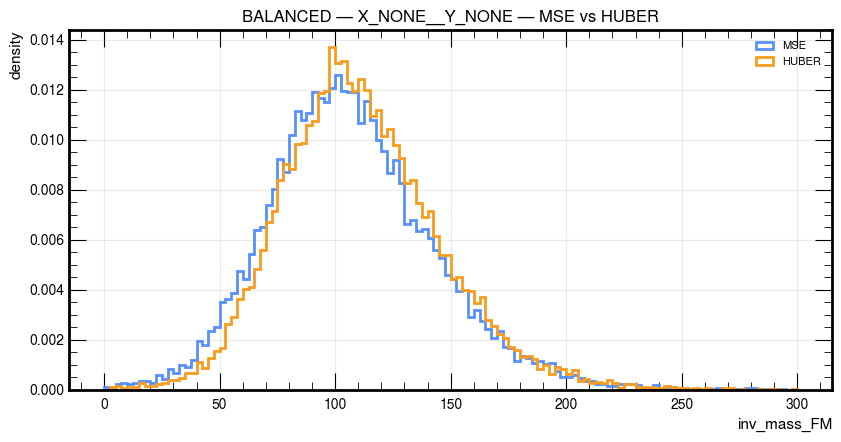

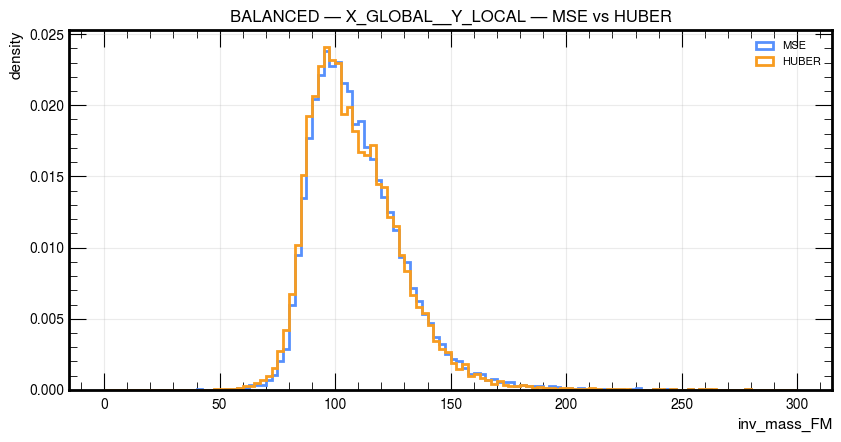

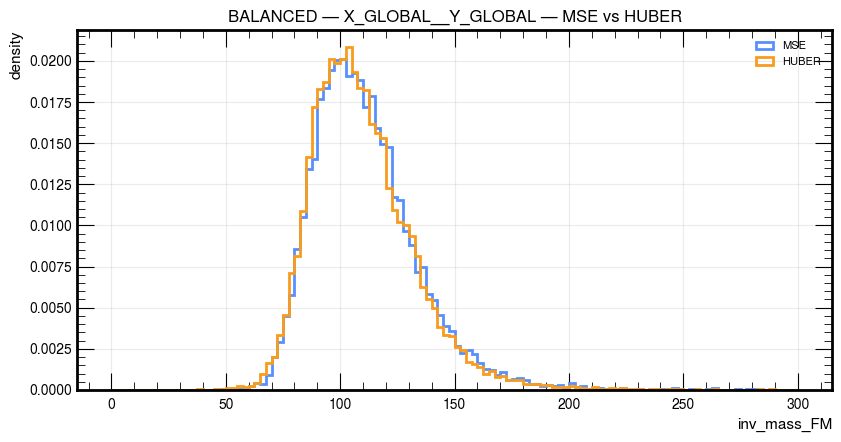

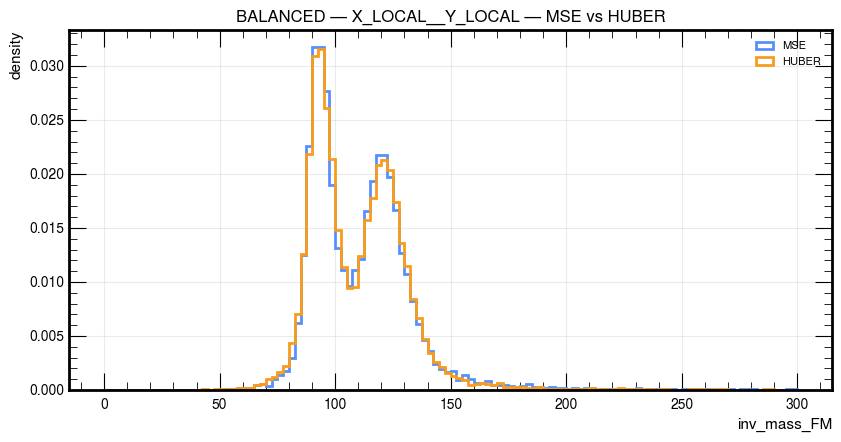

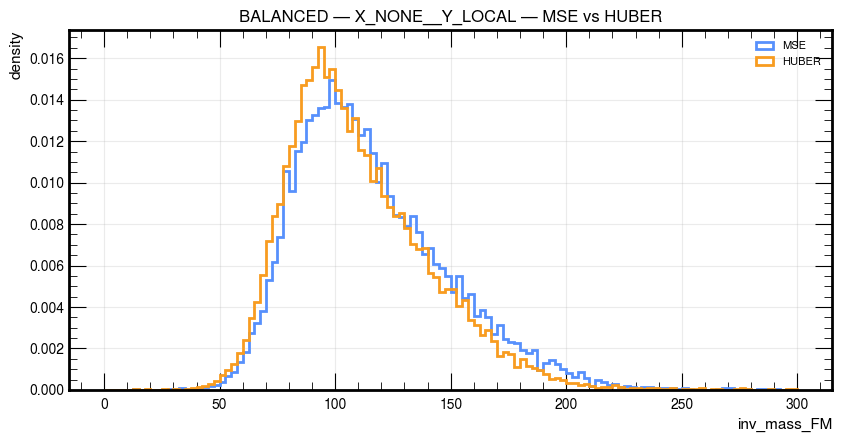

In [43]:
for mode in SCALING_MODES:

    massesPlots.plot_mass_overlay(
        {
            "MSE": masses_bal_mse[mode],
            "HUBER": masses_bal_huber[mode],
        },
        title=f"BALANCED — {mode} — MSE vs HUBER",
        bins=120,
        range_=common_range,
        density=True,
    )

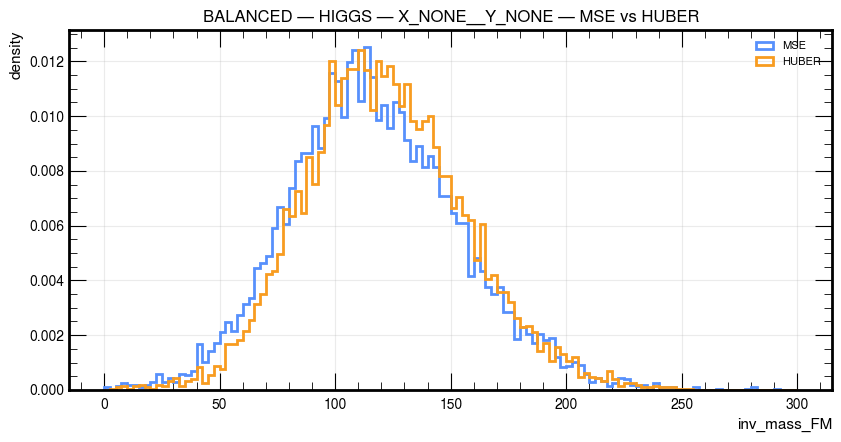

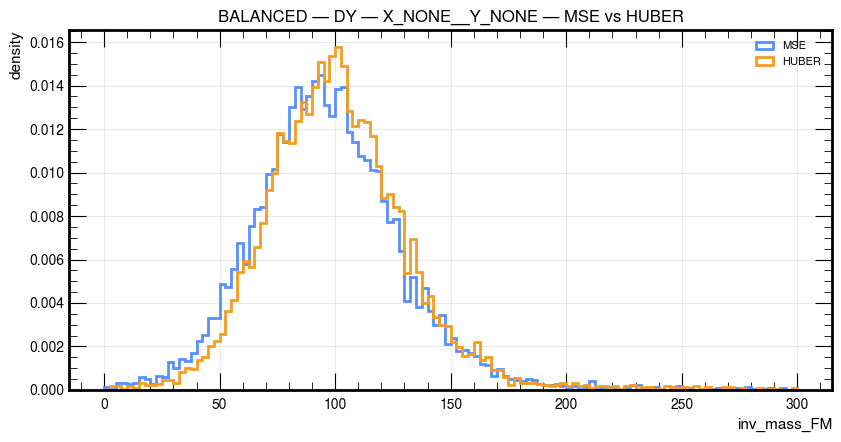

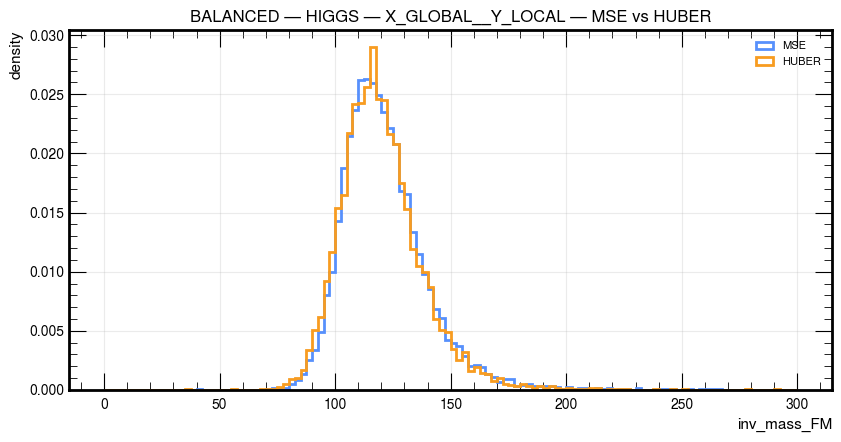

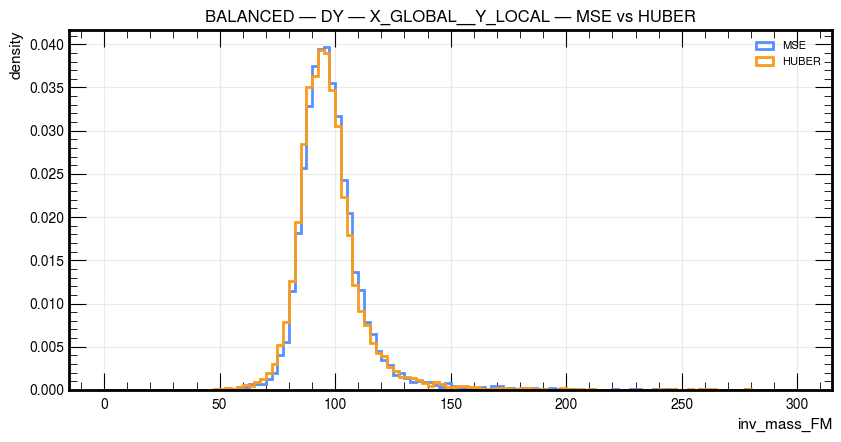

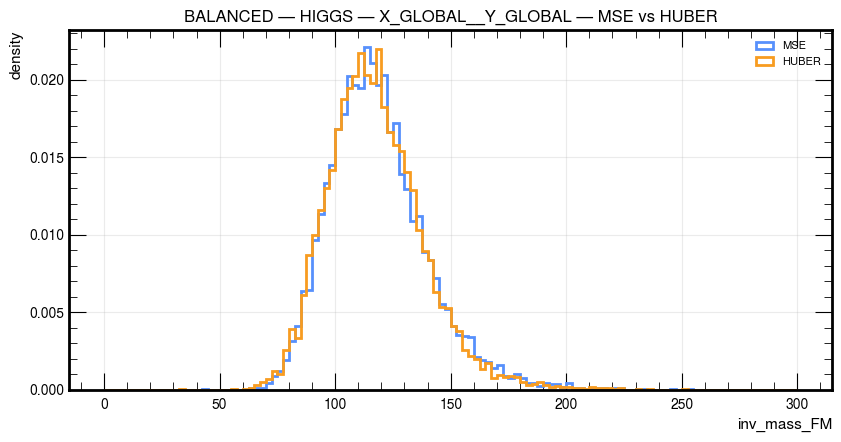

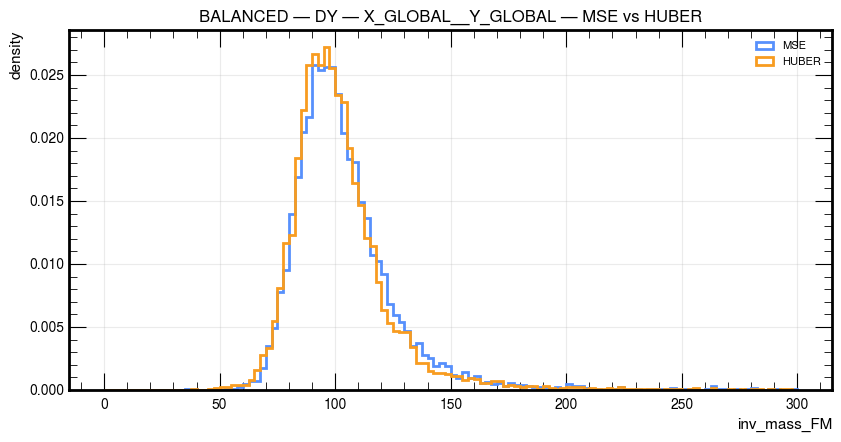

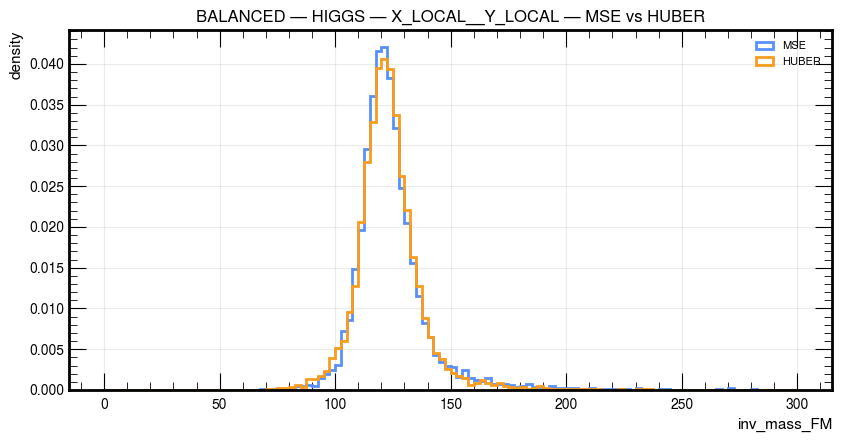

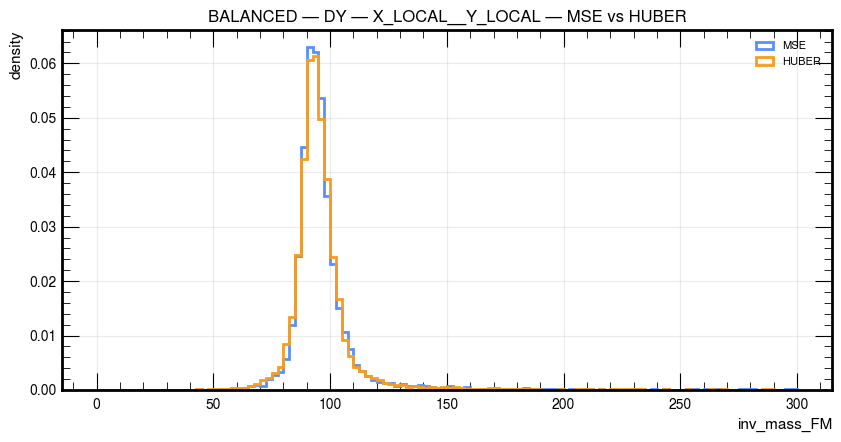

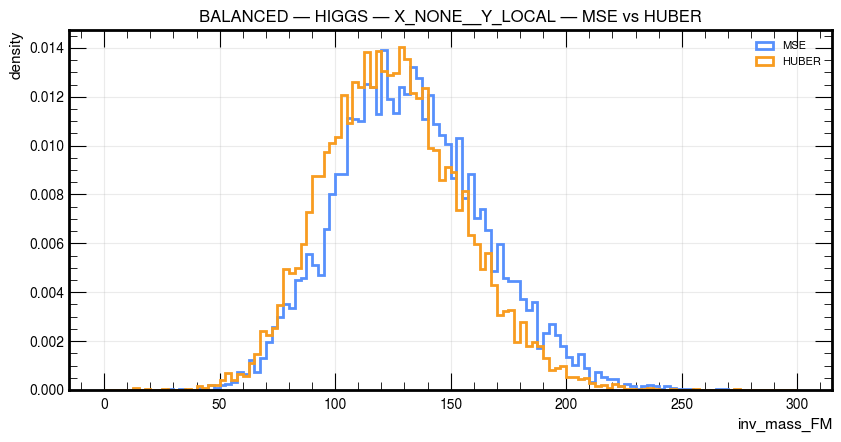

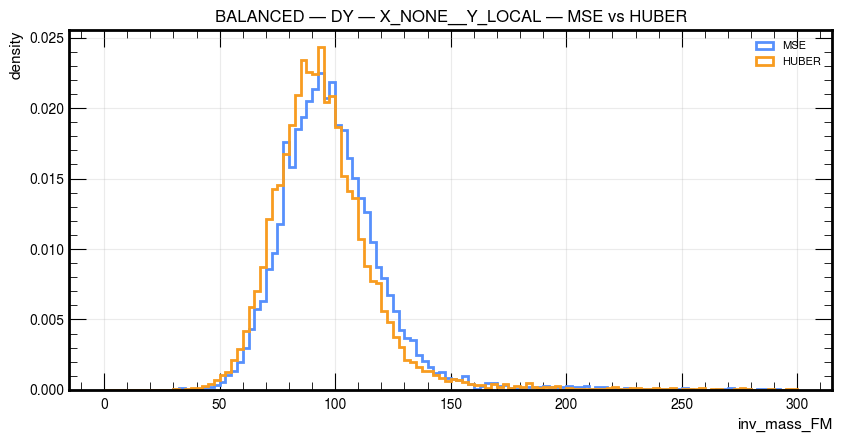

In [55]:
for mode in SCALING_MODES:
    massesPlots.plot_mass_overlay(
        {
            "MSE": masses_bal_h[mode],
            "HUBER": masses_bal_h_huber[mode],
        },
        title=f"BALANCED — HIGGS — {mode} — MSE vs HUBER",
        bins=120,
        range_=common_range,
        density=True,
    )
    massesPlots.plot_mass_overlay(
        {
            "MSE": masses_bal_dy[mode],
            "HUBER": masses_bal_dy_huber[mode],
        },
        title=f"BALANCED — DY — {mode} — MSE vs HUBER",
        bins=120,
        range_=common_range,
        density=True,
    )

In [46]:
df_sob_mse, df_sob_pivot_mse = analysis.compute_S_over_B_all_modes(
    masses_bal=masses_bal_mse,
    masses_unbal=masses_unbal_mse,
    df_test_bal=df_test_bal,
    df_test_unbal=df_test_all,
    scaling_modes=SCALING_MODES,
    window=(110, 130),
)

df_sob_huber, df_sob_pivot_huber = analysis.compute_S_over_B_all_modes(
    masses_bal=masses_bal_huber,
    masses_unbal=masses_unbal_huber,
    df_test_bal=df_test_bal,
    df_test_unbal=df_test_all,
    scaling_modes=SCALING_MODES,
    window=(110, 130),
)

df_compare = df_sob_pivot_mse.merge(
    df_sob_pivot_huber,
    on="mode",
    suffixes=("_MSE", "_HUBER"),
)

df_compare

,mode,balanced_MSE,unbalanced_MSE,balanced_HUBER,unbalanced_HUBER
0,X_GLOBAL__Y_GLOBAL,1.955527,5.275522,2.216040,5.462126
1,X_GLOBAL__Y_LOCAL,4.621524,12.983660,5.122503,12.179748
2,X_LOCAL__Y_LOCAL,15.219718,143.071006,14.930168,105.376289
3,X_NONE__Y_LOCAL,1.384347,9.146318,2.029135,9.577478
4,X_NONE__Y_NONE,1.178064,3.964674,1.124096,4.160078


To sum up:
- Il best mode resta X_LOCAL__Y_LOCAL
- S/B migliore è per X_LOCAL__Y_LOCAL unbalanced con MSE

In [47]:
df_compare["Δ_balanced_%"] = 100 * (
    df_compare["balanced_HUBER"] - df_compare["balanced_MSE"]
) / df_compare["balanced_MSE"]

df_compare["Δ_unbalanced_%"] = 100 * (
    df_compare["unbalanced_HUBER"] - df_compare["unbalanced_MSE"]
) / df_compare["unbalanced_MSE"]

df_compare

,mode,balanced_MSE,unbalanced_MSE,balanced_HUBER,unbalanced_HUBER,Δ_balanced_%,Δ_unbalanced_%
0,X_GLOBAL__Y_GLOBAL,1.955527,5.275522,2.216040,5.462126,13.321887,3.537173
1,X_GLOBAL__Y_LOCAL,4.621524,12.983660,5.122503,12.179748,10.840143,-6.191719
2,X_LOCAL__Y_LOCAL,15.219718,143.071006,14.930168,105.376289,-1.902471,-26.346860
3,X_NONE__Y_LOCAL,1.384347,9.146318,2.029135,9.577478,46.577116,4.714034
4,X_NONE__Y_NONE,1.178064,3.964674,1.124096,4.160078,-4.581014,4.928632
